
# EVnew2Revised - fixed modeling flow

This version restores the stronger forecasting logic from the older `EVnew2` notebook while still reporting all four required outputs:
- PSO-TCN
- GA-TCN
- SARIMA-PSO-TCN
- SARIMA-GA-TCN

Main fixes:
- Uses a real 1D convolutional TCN-style model instead of a plain Dense network.
- Restores hourly seasonality (`24`) and a `24`-step lookback window.
- Trains hybrid models on **SARIMA residuals** instead of adding SARIMA to a standalone TCN forecast.
- Aligns train/test windows correctly so R2 is computed on matching targets.
- Keeps GA/PSO hyperparameters within valid bounds.


In [1]:

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping

import pyswarms as ps
from deap import base, creator, tools, algorithms

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


In [2]:

file_path = "cleandata.csv"
if not os.path.exists(file_path):
    raise FileNotFoundError(
        "cleandata.csv was not found. Place it in the same folder as this notebook before running all cells."
    )

df = pd.read_csv(file_path)

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.sort_values("timestamp")

if "demand_kWh" in df.columns:
    target_col = "demand_kWh"
else:
    target_col = df.columns[1]

data = df[[target_col]].astype(float).values

train_size = int(len(data) * 0.8)
train_raw = data[:train_size]
test_raw = data[train_size:]

scaler = MinMaxScaler()
train = scaler.fit_transform(train_raw)
test = scaler.transform(test_raw)

print(f"Target column: {target_col}")
print(f"Train size: {len(train_raw)}")
print(f"Test size: {len(test_raw)}")


Target column: demand_kWh
Train size: 41539
Test size: 10385


In [3]:

window = 24
sarima_order = (2, 1, 2)
sarima_seasonal_order = (1, 1, 1, 24)


def create_sequences(series, window=24):
    series = np.asarray(series).reshape(-1)
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i + window])
        y.append(series[i + window])
    return np.array(X), np.array(y)


def sanitize_params(filters, kernel_size, lr):
    filters = int(np.clip(np.round(filters), 16, 128))
    kernel_size = int(np.clip(np.round(kernel_size), 2, min(5, window)))
    lr = float(np.clip(lr, 1e-4, 1e-2))
    return filters, kernel_size, lr


def build_tcn(filters, kernel_size, lr):
    filters, kernel_size, lr = sanitize_params(filters, kernel_size, lr)

    model = Sequential([
        Input(shape=(window, 1)),
        Conv1D(filters=filters, kernel_size=kernel_size, activation="relu", padding="causal"),
        Flatten(),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss="mse")
    return model


def smape(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1e-8, denom)
    return 100 / len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / denom)


def evaluate(name, actual, predicted):
    actual = np.asarray(actual).reshape(-1)
    predicted = np.asarray(predicted).reshape(-1)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    smape_val = smape(actual, predicted)
    r2 = r2_score(actual, predicted)

    print()
    print(f"{name} RESULTS")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"SMAPE: {smape_val:.2f}%")
    print(f"R2: {r2:.4f}")

    return mae, rmse, smape_val, r2


def run_pso_optimizer(fitness_fn, n_particles=5, iters=5):
    bounds = ([16, 2, 0.0001], [128, 5, 0.01])
    optimizer = ps.single.GlobalBestPSO(
        n_particles=n_particles,
        dimensions=3,
        options={"c1": 0.5, "c2": 0.3, "w": 0.9},
        bounds=bounds,
    )

    best_cost, best_pos = optimizer.optimize(
        lambda x: np.array([fitness_fn(p[0], p[1], p[2]) for p in x]),
        iters=iters,
    )
    return sanitize_params(*best_pos), best_cost


def run_ga_optimizer(fitness_fn, tag="Generic", pop_size=5, ngen=5):
    fit_name = f"FitnessMin_{tag}"
    ind_name = f"Individual_{tag}"

    if hasattr(creator, fit_name):
        delattr(creator, fit_name)
    if hasattr(creator, ind_name):
        delattr(creator, ind_name)

    creator.create(fit_name, base.Fitness, weights=(-1.0,))
    creator.create(ind_name, list, fitness=getattr(creator, fit_name))

    toolbox = base.Toolbox()
    toolbox.register("filters", random.randint, 16, 128)
    toolbox.register("kernel", random.randint, 2, 5)
    toolbox.register("lr", random.uniform, 0.0001, 0.01)
    toolbox.register(
        "individual",
        tools.initCycle,
        getattr(creator, ind_name),
        (toolbox.filters, toolbox.kernel, toolbox.lr),
        n=1,
    )
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_individual(individual):
        return (fitness_fn(individual[0], individual[1], individual[2]),)

    def mutate_bounded(individual, indpb=0.2):
        if random.random() < indpb:
            individual[0] = random.randint(16, 128)
        if random.random() < indpb:
            individual[1] = random.randint(2, 5)
        if random.random() < indpb:
            individual[2] = random.uniform(0.0001, 0.01)
        return individual,

    toolbox.register("evaluate", eval_individual)
    toolbox.register("mate", tools.cxBlend, alpha=0.5)
    toolbox.register("mutate", mutate_bounded)
    toolbox.register("select", tools.selTournament, tournsize=3)

    population = toolbox.population(n=pop_size)
    algorithms.eaSimple(population, toolbox, cxpb=0.5, mutpb=0.2, ngen=ngen, verbose=False)
    best_ind = tools.selBest(population, k=1)[0]
    return sanitize_params(*best_ind)


def recursive_forecast(model, history, steps, window):
    history = list(np.asarray(history).reshape(-1))
    if len(history) < window:
        history = [0.0] * (window - len(history)) + history

    forecasts = []
    for _ in range(steps):
        x_input = np.array(history[-window:]).reshape(1, window, 1)
        pred = model.predict(x_input, verbose=0).flatten()[0]
        forecasts.append(pred)
        history.append(pred)
    return np.array(forecasts)


In [4]:

# --- Standalone PSO-TCN / GA-TCN setup ---
series_train = train.flatten()
series_test = test.flatten()

X_train_seq, y_train_seq = create_sequences(series_train, window)
X_train_seq = X_train_seq.reshape((-1, window, 1))

combined_test_series = np.concatenate([series_train[-window:], series_test])
X_test_seq, y_test_seq = create_sequences(combined_test_series, window)
X_test_seq = X_test_seq.reshape((-1, window, 1))

val_split = max(1, int(len(X_train_seq) * 0.8))
val_split = min(val_split, len(X_train_seq) - 1)

X_series_fit = X_train_seq[:val_split]
y_series_fit = y_train_seq[:val_split]
X_series_val = X_train_seq[val_split:]
y_series_val = y_train_seq[val_split:]


def series_fitness(filters, kernel_size, lr):
    model = build_tcn(filters, kernel_size, lr)
    model.fit(X_series_fit, y_series_fit, epochs=3, batch_size=32, verbose=0)
    pred = model.predict(X_series_val, verbose=0).flatten()
    return mean_squared_error(y_series_val, pred)


In [5]:

# --- PSO-TCN optimization and training ---
(pso_filters, pso_kernel, pso_lr), pso_cost = run_pso_optimizer(series_fitness)
print("PSO-TCN Best Hyperparameters:", (pso_filters, pso_kernel, pso_lr))

pso_model = build_tcn(pso_filters, pso_kernel, pso_lr)
pso_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=15,
    batch_size=32,
    verbose=0,
    callbacks=[EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)],
)

pso_pred_scaled = pso_model.predict(X_test_seq, verbose=0).flatten()
pso_pred = scaler.inverse_transform(pso_pred_scaled.reshape(-1, 1)).flatten()


2026-04-20 13:43:13,375 - pyswarms.single.global_best - INFO - Optimize for 5 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|███████████████████████████████████████████████████████████████|5/5, best_cost=0.0059
2026-04-20 13:48:45,094 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.005898302041767599, best pos: [1.22275180e+02 4.89689610e+00 8.10313375e-03]


PSO-TCN Best Hyperparameters: (122, 5, 0.008103133746352966)


In [6]:

# --- GA-TCN optimization and training ---
ga_filters, ga_kernel, ga_lr = run_ga_optimizer(series_fitness, tag="Series")
print("GA-TCN Best Hyperparameters:", (ga_filters, ga_kernel, ga_lr))

ga_model = build_tcn(ga_filters, ga_kernel, ga_lr)
ga_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=15,
    batch_size=32,
    verbose=0,
    callbacks=[EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)],
)

ga_pred_scaled = ga_model.predict(X_test_seq, verbose=0).flatten()
ga_pred = scaler.inverse_transform(ga_pred_scaled.reshape(-1, 1)).flatten()

actual = test_raw.flatten()
metrics_pso_tcn = evaluate("PSO-TCN", actual, pso_pred)
metrics_ga_tcn = evaluate("GA-TCN", actual, ga_pred)


GA-TCN Best Hyperparameters: (60, 4, 0.008090569905416364)

PSO-TCN RESULTS
MAE: 9.5404
RMSE: 13.3998
SMAPE: 30.55%
R2: 0.8680

GA-TCN RESULTS
MAE: 9.4778
RMSE: 13.3677
SMAPE: 30.20%
R2: 0.8686


In [7]:

# --- SARIMA baseline and residual series for hybrid models ---
sarima = SARIMAX(
    series_train,
    order=sarima_order,
    seasonal_order=sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_fit = sarima.fit(method="powell", maxiter=200, disp=False)

sarima_train_fitted = np.asarray(sarima_fit.fittedvalues).reshape(-1)
sarima_train_fitted = np.nan_to_num(sarima_train_fitted, nan=0.0, posinf=0.0, neginf=0.0)

train_residuals = series_train - sarima_train_fitted
sarima_test_scaled = np.asarray(sarima_fit.forecast(steps=len(series_test))).reshape(-1)

X_res_train, y_res_train = create_sequences(train_residuals, window)
X_res_train = X_res_train.reshape((-1, window, 1))

res_split = max(1, int(len(X_res_train) * 0.8))
res_split = min(res_split, len(X_res_train) - 1)

X_res_fit = X_res_train[:res_split]
y_res_fit = y_res_train[:res_split]
X_res_val = X_res_train[res_split:]
y_res_val = y_res_train[res_split:]


def residual_fitness(filters, kernel_size, lr):
    model = build_tcn(filters, kernel_size, lr)
    model.fit(X_res_fit, y_res_fit, epochs=3, batch_size=32, verbose=0)
    pred = model.predict(X_res_val, verbose=0).flatten()
    return mean_squared_error(y_res_val, pred)


In [8]:

# --- SARIMA-PSO-TCN hybrid ---
(hybrid_pso_filters, hybrid_pso_kernel, hybrid_pso_lr), hybrid_pso_cost = run_pso_optimizer(
    residual_fitness
)
print("SARIMA-PSO-TCN Best Residual Hyperparameters:", (hybrid_pso_filters, hybrid_pso_kernel, hybrid_pso_lr))

hybrid_pso_model = build_tcn(hybrid_pso_filters, hybrid_pso_kernel, hybrid_pso_lr)
hybrid_pso_model.fit(
    X_res_train,
    y_res_train,
    epochs=15,
    batch_size=32,
    verbose=0,
    callbacks=[EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)],
)

res_pso_scaled = recursive_forecast(hybrid_pso_model, train_residuals, len(series_test), window)
final_pso_scaled = sarima_test_scaled + res_pso_scaled
final_pso = scaler.inverse_transform(final_pso_scaled.reshape(-1, 1)).flatten()


2026-04-20 14:04:29,239 - pyswarms.single.global_best - INFO - Optimize for 5 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████████████████████████████████████████████████████████|5/5, best_cost=0.00528
2026-04-20 14:09:57,371 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.00527527544641081, best pos: [1.21331361e+02 4.86178573e+00 9.15715746e-03]


SARIMA-PSO-TCN Best Residual Hyperparameters: (121, 5, 0.009157157463182441)


In [10]:

# --- SARIMA-GA-TCN hybrid ---
hybrid_ga_filters, hybrid_ga_kernel, hybrid_ga_lr = run_ga_optimizer(residual_fitness, tag="Residual")
print("SARIMA-GA-TCN Best Residual Hyperparameters:", (hybrid_ga_filters, hybrid_ga_kernel, hybrid_ga_lr))

hybrid_ga_model = build_tcn(hybrid_ga_filters, hybrid_ga_kernel, hybrid_ga_lr)
hybrid_ga_model.fit(
    X_res_train,
    y_res_train,
    epochs=15,
    batch_size=32,
    verbose=0,
    callbacks=[EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)],
)

res_ga_scaled = recursive_forecast(hybrid_ga_model, train_residuals, len(series_test), window)
final_ga_scaled = sarima_test_scaled + res_ga_scaled
final_ga = scaler.inverse_transform(final_ga_scaled.reshape(-1, 1)).flatten()

metrics_sarima_pso = evaluate("SARIMA-PSO-TCN", actual, final_pso)
metrics_sarima_ga = evaluate("SARIMA-GA-TCN", actual, final_ga)


SARIMA-GA-TCN Best Residual Hyperparameters: (27, 3, 0.009750394421351545)

SARIMA-PSO-TCN RESULTS
MAE: 16.9088
RMSE: 23.3575
SMAPE: 45.97%
R2: 0.5989

SARIMA-GA-TCN RESULTS
MAE: 16.9248
RMSE: 23.3598
SMAPE: 45.92%
R2: 0.5988


In [11]:
summary = pd.DataFrame({
    "Model": ["PSO-TCN", "GA-TCN", "SARIMA-PSO-TCN", "SARIMA-GA-TCN"],
    "Filters": [pso_filters, ga_filters, hybrid_pso_filters, hybrid_ga_filters],
    "Kernel": [pso_kernel, ga_kernel, hybrid_pso_kernel, hybrid_ga_kernel],
    "Learning Rate": [pso_lr, ga_lr, hybrid_pso_lr, hybrid_ga_lr],
    "MAE": [metrics_pso_tcn[0], metrics_ga_tcn[0], metrics_sarima_pso[0], metrics_sarima_ga[0]],
    "RMSE": [metrics_pso_tcn[1], metrics_ga_tcn[1], metrics_sarima_pso[1], metrics_sarima_ga[1]],
    "SMAPE": [metrics_pso_tcn[2], metrics_ga_tcn[2], metrics_sarima_pso[2], metrics_sarima_ga[2]],
    "R2": [metrics_pso_tcn[3], metrics_ga_tcn[3], metrics_sarima_pso[3], metrics_sarima_ga[3]],
})

print()
print("FINAL HYPERPARAMETER AND METRIC SUMMARY")
print(summary)



FINAL HYPERPARAMETER AND METRIC SUMMARY
            Model  Filters  Kernel  Learning Rate        MAE       RMSE  \
0         PSO-TCN      122       5       0.008103   9.540389  13.399813   
1          GA-TCN       60       4       0.008091   9.477782  13.367662   
2  SARIMA-PSO-TCN      121       5       0.009157  16.908768  23.357502   
3   SARIMA-GA-TCN       27       3       0.009750  16.924790  23.359755   

       SMAPE        R2  
0  30.548777  0.867993  
1  30.201000  0.868626  
2  45.972741  0.598900  
3  45.916051  0.598823  


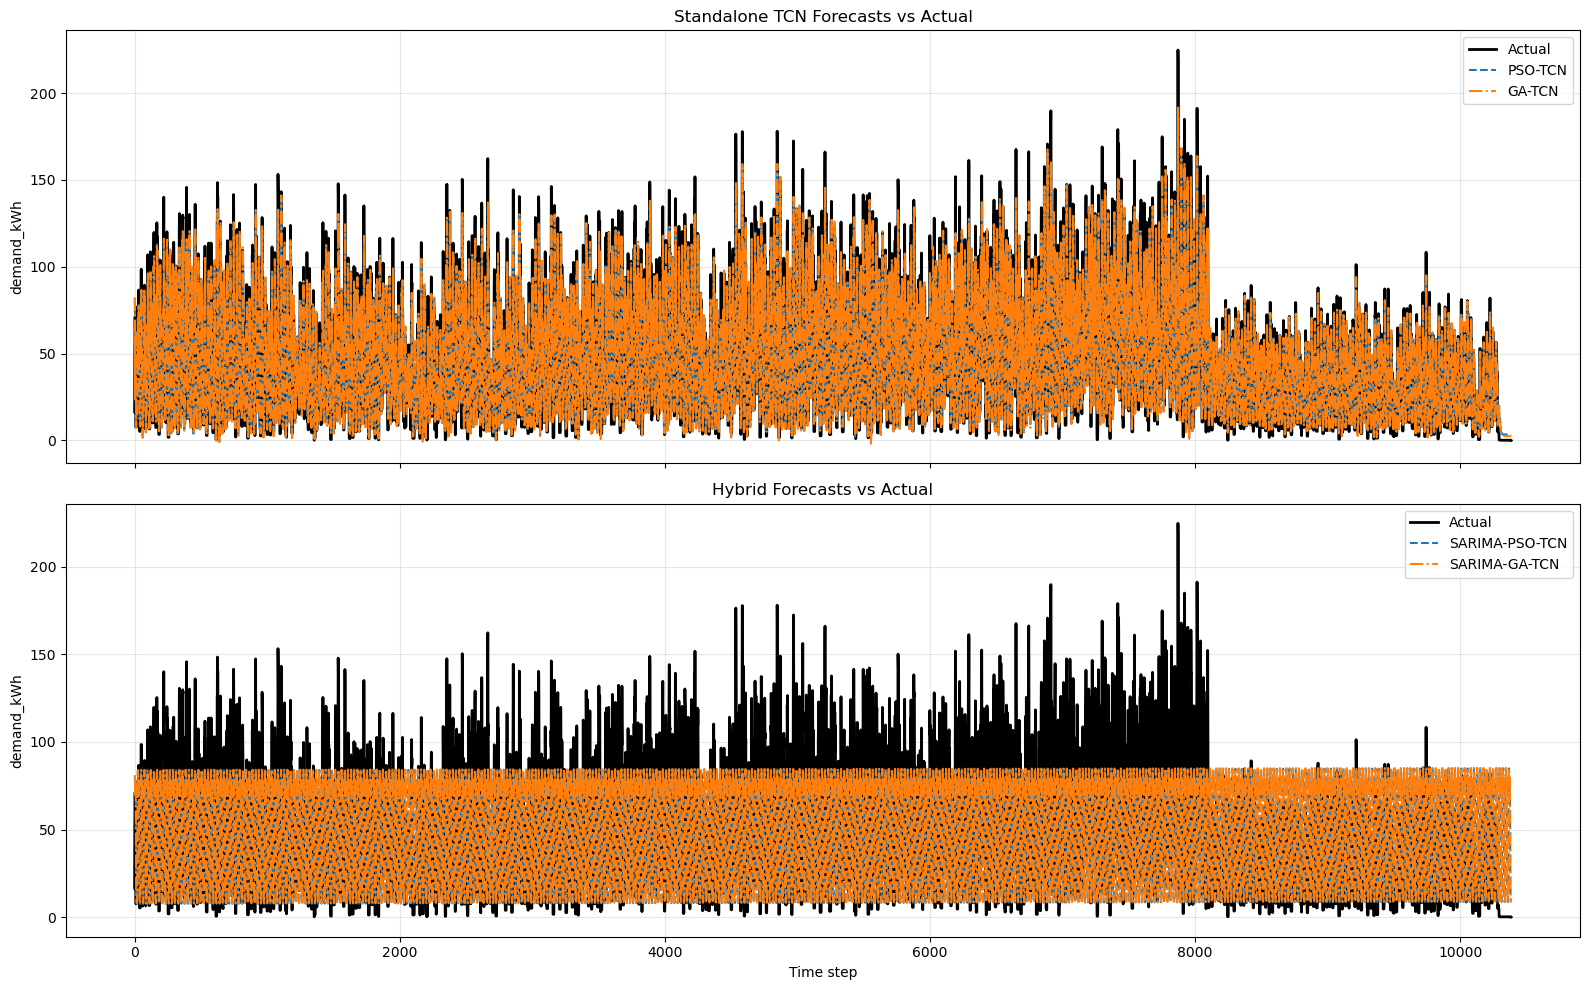

In [12]:

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

axes[0].plot(actual, label="Actual", color="black", linewidth=2)
axes[0].plot(pso_pred, label="PSO-TCN", linestyle="--")
axes[0].plot(ga_pred, label="GA-TCN", linestyle="-.")
axes[0].set_title("Standalone TCN Forecasts vs Actual")
axes[0].set_ylabel(f"{target_col}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(actual, label="Actual", color="black", linewidth=2)
axes[1].plot(final_pso, label="SARIMA-PSO-TCN", linestyle="--")
axes[1].plot(final_ga, label="SARIMA-GA-TCN", linestyle="-.")
axes[1].set_title("Hybrid Forecasts vs Actual")
axes[1].set_xlabel("Time step")
axes[1].set_ylabel(f"{target_col}")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
